# Continuous-Time Koopman Dynamics for Irregularly-Sampled Graphs

**Synthetic identifiability tutorial.** This notebook demonstrates continuous-time Koopman
integration on a *known* linear system with irregular sampling intervals. It is **not** an
end-to-end METR-LA traffic forecasting walkthrough — that workflow lives in
[`03_traffic_network.ipynb`](03_traffic_network.ipynb) (temporal splits, per-horizon metrics,
DMD baseline).

## What this notebook demonstrates

1. **Generator learning.** Fit `ContinuousKoopmanOperator` to irregularly timed pairs and
   recover the true generator spectrum `L✱` (Section 3).
2. **Δt-awareness.** Continuous one-step error stays flat across sampling gaps; a fixed-step
   discrete operator degrades off its assumed step (Section 4).
3. **API contract.** `GraphKoopmanModel(dynamics_mode="continuous").predict_at(query_times=...)`
   forecasts at arbitrary horizons; discrete mode rejects off-grid queries (Section 5).

## Motivation: why continuous time?

Graph telemetry (traffic, power, sensor networks) is often **irregularly sampled**:
inter-reading intervals vary. A discrete Koopman step $z_{t+1} = z_t K^\top$
bakes in a *fixed* $\Delta t$ and cannot represent a variable one.
Continuous-time KoopmanGraph instead learns a **generator** $L$ and integrates
with a matrix exponential (standard continuous-time Koopman / matrix semigroup):

$$K(\Delta t) = \exp(L \cdot \Delta t).$$

The library advances row latents as $z_{t+\Delta t} = z_t\, K(\Delta t)^\top$
(equivalently $\dot z = z L^\top$). Sections 1–4 below use **column-vector**
1D states $z(t)=\exp(L t)\,z_0$ for clarity; for length-$d$ vectors the two
layouts are numerically equivalent. To verify the mechanism in isolation, we
use a synthetic system with a *known* $L^\star$ rather than real traffic caches
(see **Related examples** at the end).

## Why not METR-LA here?

Two confounds block a fair real-data demo in this notebook:

1. **Forecastability.** On short, per-sensor z-scored METR-LA windows the step residual is
   near white noise — the MSE-optimal forecast is a flat mean line, so no operator can
   (or should) trace the fluctuations. That is a property of the data, not of continuous vs.
   discrete integration.
2. **GNN autoencoder error.** Encoder/decoder reconstruction is common-mode to both models and
   can dominate, masking the Δt effect we want to isolate.

So we build the column ODE $\dot z = L^\star z$, sample it at irregular times, and fit
the library's operators directly. Section 5 then exercises the end-to-end
`GraphKoopmanModel.predict_at` API on a graph sequence built from the same synthetic
dynamics.


In [1]:
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data

from koopman_graph import (
    ContinuousKoopmanOperator,
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    GraphSnapshotSequence,
    KoopmanOperator,
    LossWeights,
)
from koopman_graph.analysis import compute_generator_spectrum

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")
    warnings.filterwarnings("ignore")

torch.manual_seed(0)

## 1. A known continuous-time system

We choose a stable generator $L^\star$ with two oscillatory-and-decaying modes (complex
eigenvalues with negative real parts — Hurwitz stable: $\operatorname{Re}(\lambda)<0$).
Using column-vector notation for this 1D demo, the exact trajectory is
$z(t) = \exp(L^\star t)\, z_0$, which we observe at **irregular** times with
inter-sample gaps spanning $0.3\times$ to $3\times$ a nominal step.


In [2]:
def rotation_block(decay: float, freq: float) -> torch.Tensor:
    """2x2 generator block with eigenvalues decay ± i·freq."""
    return torch.tensor([[decay, -freq], [freq, decay]])


generator_true = torch.zeros(4, 4)
generator_true[:2, :2] = rotation_block(-0.10, 1.4)
generator_true[2:, 2:] = rotation_block(-0.30, 0.5)
eigs_true = torch.linalg.eigvals(generator_true)

base_dt = 0.25  # nominal step a fixed-rate sensor would assume
z0 = torch.tensor([1.0, 0.2, -0.5, 0.8])


def irregular_times(num: int, seed: int) -> torch.Tensor:
    gen = torch.Generator().manual_seed(seed)
    gaps = base_dt * (0.3 + 2.7 * torch.rand(num - 1, generator=gen))
    times = torch.zeros(num)
    times[1:] = gaps.cumsum(dim=0)
    return times


def trajectory(times: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.matrix_exp(generator_true * float(t)) @ z0 for t in times])


train_times = irregular_times(120, seed=1)
Z_train = trajectory(train_times)
train_gaps = train_times[1:] - train_times[:-1]

print("true generator eigenvalues:", [complex(round(e.real.item(), 3), round(e.imag.item(), 3)) for e in eigs_true])
print(f"train samples: {Z_train.shape[0]}, Δt range: {float(train_gaps.min()):.3f}–{float(train_gaps.max()):.3f} (nominal {base_dt})")

true generator eigenvalues: [(-0.1+1.4j), (-0.1-1.4j), (-0.3+0.5j), (-0.3-0.5j)]
train samples: 120, Δt range: 0.083–0.749 (nominal 0.25)


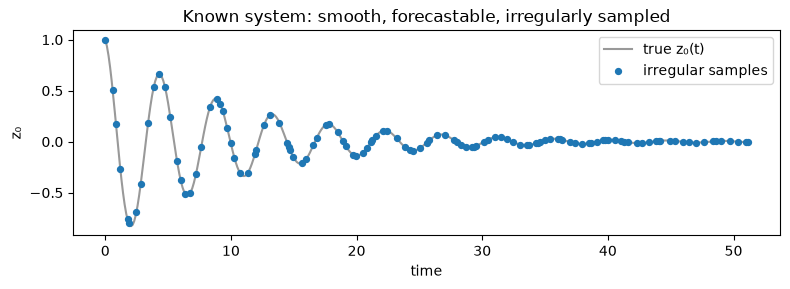

In [3]:
dense_times = torch.linspace(0.0, float(train_times[-1]), 400)
Z_dense = trajectory(dense_times)

plt.figure(figsize=(8, 3))
plt.plot(dense_times, Z_dense[:, 0], color="0.6", label="true z₀(t)")
plt.scatter(train_times, Z_train[:, 0], s=18, color="C0", zorder=3, label="irregular samples")
plt.xlabel("time")
plt.ylabel("z₀")
plt.title("Known system: smooth, forecastable, irregularly sampled")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Fit continuous vs. discrete operators to the *same* irregular pairs

Both operators see identical `(z_i, z_{i+1})` pairs. The **continuous** operator also
receives each pair's true `Δt` and propagates with `exp(L·Δt)`. The **discrete** operator
has no notion of `Δt`: it applies a single fixed `K` per step — the standard assumption
that breaks under irregular sampling.

In [4]:
z_in, z_out = Z_train[:-1], Z_train[1:]

continuous_op = ContinuousKoopmanOperator(latent_dim=4, parameterization="dense", init_scale=0.1)
discrete_op = KoopmanOperator(latent_dim=4)

opt_c = torch.optim.Adam(continuous_op.parameters(), lr=1e-2)
opt_d = torch.optim.Adam(discrete_op.parameters(), lr=1e-2)

for _ in range(1500):
    opt_c.zero_grad()
    # K(Δt_i) = exp(L·Δt_i) for every pair, then propagate (advance() is the per-sample wrapper).
    K_batch = torch.matrix_exp(continuous_op.L * train_gaps[:, None, None])
    pred_c = torch.bmm(K_batch, z_in.unsqueeze(-1)).squeeze(-1)
    loss_c = ((pred_c - z_out) ** 2).mean()
    loss_c.backward()
    opt_c.step()

    opt_d.zero_grad()
    loss_d = ((discrete_op(z_in) - z_out) ** 2).mean()
    loss_d.backward()
    opt_d.step()

print(f"final train MSE  —  continuous: {float(loss_c):.2e}   discrete (fixed K): {float(loss_d):.2e}")

final train MSE  —  continuous: 5.48e-13   discrete (fixed K): 1.23e-03


/var/folders/_j/45bljkj97jd5f7y7xgm6bpyr0000gn/T/ipykernel_59085/3706777835.py:23: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  print(f"final train MSE  —  continuous: {float(loss_c):.2e}   discrete (fixed K): {float(loss_d):.2e}")


## 3. The continuous operator recovers the true generator

Because we know `L✱`, we can check recovery directly via the spectrum. A discrete fixed-step
operator has no single generator consistent with irregular gaps, so there is nothing to
recover — this is the crux of the limitation.

In [5]:
spectrum = compute_generator_spectrum(continuous_op.L.detach())


def sort_key(values):
    return sorted((round(v.real.item(), 3), round(v.imag.item(), 3)) for v in values)


print("true    eigenvalues:", sort_key(eigs_true))
print("learned eigenvalues:", sort_key(spectrum.eigenvalues))
max_real_err = (torch.sort(spectrum.eigenvalues.real).values - torch.sort(eigs_true.real).values).abs().max()
max_imag_err = (torch.sort(spectrum.eigenvalues.imag).values - torch.sort(eigs_true.imag).values).abs().max()
assert float(max_real_err) < 1e-2, f"real-part recovery failed: {float(max_real_err)}"
assert float(max_imag_err) < 1e-2, f"imag-part recovery failed: {float(max_imag_err)}"
assert bool(torch.all(spectrum.growth_rates < 0)), "learned generator is not Hurwitz-stable"
print(
    f"max |d Re(lambda)| = {float(max_real_err):.2e}, "
    f"max |d Im(lambda)| = {float(max_imag_err):.2e} -- recovery OK, Hurwitz-stable"
)


true    eigenvalues: [(-0.3, -0.5), (-0.3, 0.5), (-0.1, -1.4), (-0.1, 1.4)]
learned eigenvalues: [(-0.3, -0.5), (-0.3, 0.5), (-0.1, -1.4), (-0.1, 1.4)]
max |d Re(lambda)| = 3.05e-07, max |d Im(lambda)| = 3.58e-07 -- recovery OK, Hurwitz-stable


## 4. The payoff: continuous tracks the trajectory at arbitrary times

On a **held-out** irregular trajectory we measure one-step prediction error as a function
of `Δt`. The continuous operator is accurate across all intervals, while one fixed discrete
operator cannot simultaneously fit the variable-interval transitions.

The first figure shows one-step error across the sampled intervals. The second forecasts
from `z_0` and focuses on `0 ≤ t ≤ 30`, where the transient dynamics are visually
informative: continuous predictions land **on** the true curve at the true irregular
times, while the discrete rollout (uniform steps only) drifts.

In [6]:
test_times = irregular_times(160, seed=7)
Z_test = trajectory(test_times)
test_gaps = test_times[1:] - test_times[:-1]

with torch.no_grad():
    err_cont, err_disc = [], []
    for i in range(len(Z_test) - 1):
        pred_c = continuous_op.advance(Z_test[i], float(test_gaps[i]))
        pred_d = discrete_op(Z_test[i])
        err_cont.append(float((pred_c - Z_test[i + 1]).abs().mean()))
        err_disc.append(float((pred_d - Z_test[i + 1]).abs().mean()))

mae_cont = sum(err_cont) / len(err_cont)
mae_disc = sum(err_disc) / len(err_disc)
print(f"held-out one-step MAE  --  continuous: {mae_cont:.4f}   discrete: {mae_disc:.4f}")
assert mae_cont < 1e-3, f"continuous one-step MAE too large: {mae_cont}"
assert mae_cont < mae_disc, "continuous should beat fixed-step discrete under irregular sampling"

# Full-trajectory forecast from z0.
with torch.no_grad():
    cont_forecast = torch.stack([continuous_op.advance(z0, float(t)) for t in test_times])
    traj_err = float((cont_forecast - Z_test).abs().mean())
    assert traj_err < 1e-2, f"continuous multi-step trajectory error too large: {traj_err}"
    print(f"continuous multi-step trajectory MAE from z0: {traj_err:.2e}")
    n_uniform = int(test_times[-1] / base_dt) + 1
    uniform_times = base_dt * torch.arange(n_uniform)
    disc_forecast = [z0]
    for _ in range(n_uniform - 1):
        disc_forecast.append(discrete_op(disc_forecast[-1]))
    disc_forecast = torch.stack(disc_forecast)


held-out one-step MAE  --  continuous: 0.0000   discrete: 0.0114
continuous multi-step trajectory MAE from z0: 2.77e-07


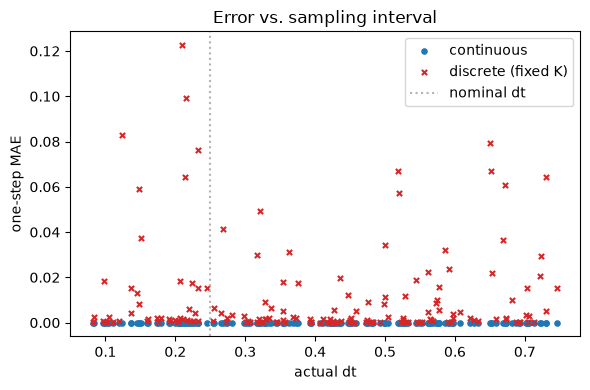

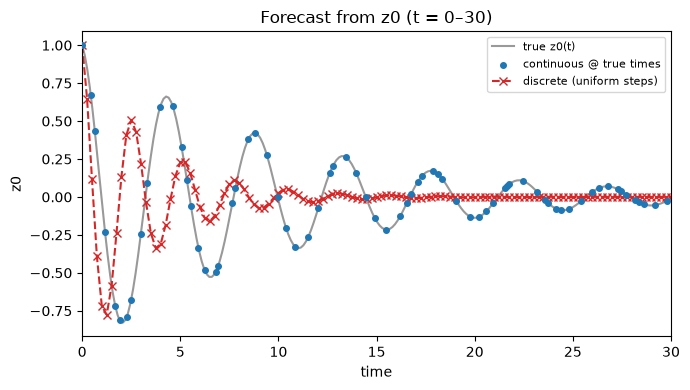

In [7]:
plot_horizon = float(max(test_times[-1], train_times[-1]))
dense_plot = torch.linspace(0.0, plot_horizon, 500)
Z_plot = trajectory(dense_plot)

plt.figure(figsize=(6, 4))
plt.scatter(test_gaps, err_cont, s=14, color="C0", label="continuous")
plt.scatter(test_gaps, err_disc, s=14, color="C3", marker="x", label="discrete (fixed K)")
plt.axvline(base_dt, color="0.7", linestyle=":", label="nominal dt")
plt.xlabel("actual dt")
plt.ylabel("one-step MAE")
plt.title("Error vs. sampling interval")
plt.legend()
plt.tight_layout()
plt.show()

forecast_horizon = 30.0
plt.figure(figsize=(7, 4))
plt.plot(dense_plot, Z_plot[:, 0], color="0.6", label="true z0(t)")
plt.scatter(
    test_times,
    cont_forecast[:, 0],
    s=16,
    color="C0",
    zorder=3,
    label="continuous @ true times",
)
plt.plot(
    uniform_times,
    disc_forecast[:, 0],
    color="C3",
    marker="x",
    linestyle="--",
    label="discrete (uniform steps)",
)
plt.xlim(0, forecast_horizon)
plt.xlabel("time")
plt.ylabel("z0")
plt.title("Forecast from z0 (t = 0–30)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. End-to-end graph API: `GraphKoopmanModel.predict_at`

The sections above isolate the mathematics. Here we exercise the **public graph API** on a
small synthetic graph sequence carrying explicit `timestamps`. The point of this section is
the *interface contract*, not a forecast-accuracy benchmark:

- a **continuous** `GraphKoopmanModel` accepts arbitrary `query_times`, and
- a **discrete** model **refuses** off-grid queries (it can only step by `time_step`).


In [8]:
num_nodes = 12
phase = torch.linspace(0, 2 * torch.pi, num_nodes + 1)[:-1]
src = torch.arange(num_nodes)
dst = (src + 1) % num_nodes
edge_index = torch.stack([torch.cat([src, dst]), torch.cat([dst, src])])

graph_times = irregular_times(40, seed=2)


def node_signal(t: float) -> torch.Tensor:
    wave = torch.exp(torch.tensor(-0.1 * t)) * torch.cos(1.2 * t + phase)
    return wave.unsqueeze(-1)


snapshots = [Data(x=node_signal(float(t)), edge_index=edge_index) for t in graph_times]
sequence = GraphSnapshotSequence(snapshots, timestamps=graph_times)

split = 30
train_seq = sequence.slice(0, split)
test_seq = sequence.slice(split, sequence.num_timesteps)
query_times = [float(test_seq.timestamps[i] - test_seq.timestamps[0]) for i in range(1, test_seq.num_timesteps)]

latent_dim = 12
graph_model = GraphKoopmanModel(
    GNNEncoder(in_channels=1, hidden_channels=32, latent_dim=latent_dim),
    GNNDecoder(latent_dim=latent_dim, hidden_channels=32, out_channels=1),
    latent_dim=latent_dim,
    time_step=base_dt,
    dynamics_mode="continuous",
    koopman_parameterization="dense",
)
graph_model.fit(train_seq, epochs=40, lr=5e-3, loss_weights=LossWeights(reconstruction=1.0, forward=1.0))

forecasts = graph_model.predict_at(test_seq[0], query_times=query_times)
print(f"continuous predict_at accepted {len(query_times)} irregular query times → {len(forecasts)} snapshots")
gen_spectrum = graph_model.spectrum()
max_growth = float(gen_spectrum.growth_rates.max())
hurwitz = max_growth < 0.0
print(
    f"learned generator: max Re(λ) = {max_growth:.3f} "
    f"(Hurwitz-stable: {hurwitz}; requires max Re(λ) < 0)"
)


continuous predict_at accepted 9 irregular query times → 9 snapshots
learned generator: max Re(λ) = 0.077 (Hurwitz-stable: False; requires max Re(λ) < 0)


In [9]:
discrete_model = GraphKoopmanModel(
    GNNEncoder(in_channels=1, hidden_channels=32, latent_dim=latent_dim),
    GNNDecoder(latent_dim=latent_dim, hidden_channels=32, out_channels=1),
    latent_dim=latent_dim,
    time_step=base_dt,
    dynamics_mode="discrete",
)

try:
    discrete_model.predict_at(test_seq[0], query_times=query_times)
    raise AssertionError("expected discrete model to reject irregular query_times")
except ValueError as exc:
    print(f"discrete model correctly rejected irregular query_times:\n  {exc}")

discrete model correctly rejected irregular query_times:
  discrete dynamics_mode requires uniform increments equal to time_step=0.25; got 0.10591316223144531. Use dynamics_mode='continuous' for irregular sampling.


## Takeaways

- **Exact recovery.** From irregularly-timed samples of a known linear system, the
  continuous operator recovers `L✱`'s spectrum to numerical precision (Section 3).
- **`Δt-awareness is the mechanism.** Continuous one-step error is flat across sampling
  intervals; the fixed-step discrete operator errs off its assumed step (Section 4).
- **API contract.** `GraphKoopmanModel(dynamics_mode="continuous").predict_at(query_times=...)`
  serves arbitrary horizons; the discrete model refuses off-grid queries (Section 5).

## Related examples

| Notebook | Scope |
|----------|-------|
| [`03_traffic_network.ipynb`](03_traffic_network.ipynb) | End-to-end METR-LA training, temporal splits, per-horizon MAE/RMSE/MAPE, topology-aware vs. vectorized DMD baseline |
| This notebook (`12`) | Synthetic theory: generator identifiability, irregular `Δt` comparison, `predict_at` API |

For real traffic forecasting with the library's evaluation protocol, start with notebook 03.
Continuous-time mode on irregularly timestamped METR-LA sequences (and missing-sensor masks)
is a separate concern — use this notebook to validate the operator and API first.